In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pygom import Event, Transition, SimulateOde
import sys
sys.path.append("C:/Users/Joseph.Gibson/OneDrive - UK Health Security Agency/pygom/src/pygom/simulation/src")

from simulation.stochastic.solve_stochastic import solve_stochastic

from simulation.deterministic.solve_deterministic import solve_deterministic

In [2]:
N = 10000
R0 = 1.5
gamma = 1 / 4.0
beta = R0 * gamma

# Params and states
params=['beta', 'gamma', 'N']
states=['S', 'I', 'R']

# Transitions
transition_infection=Transition(origin='S', destination='I', transition_type='T', magnitude='1')
event_infection=Event(transition_list=[transition_infection], rate='beta*S*I/N')

transition_recovery=Transition(origin='I', destination='R', transition_type='T', magnitude='1')
event_recovery=Event(transition_list=[transition_recovery], rate='gamma*I')

transition_names = ['new_infections', 'new_recoveries']

event_list = [event_infection, event_recovery]
model = SimulateOde(state=states, param=params, event=event_list)
model.parameters = {"beta": beta, "gamma": gamma, "N":N}

In [4]:
i0 = 20
y0 = np.array([N-i0, i0, 0])

ylims = [(0, N), (0, N), (0, N)]
ylims = np.asarray(ylims, dtype=object)  # because we have None
mins = np.array([lim[0] if lim[0] is not None else -np.inf for lim in ylims])
maxs = np.array([lim[1] if lim[1] is not None else np.inf for lim in ylims])

stoichiometry_matrix = model.state_change_matrix(y0, 0)
# event_rates = model.event_rate_vector.T
# f_mu = model.transition_mean.T
# f_var= model.transition_variance.T
# ode = model.ode.T
# jac_state = model.jacobian.T
# jac_rates = model.rates_jacobian.T

n_state, n_event = stoichiometry_matrix.shape

prob_failure = (1/R0)**i0
print(f"Prob failure: {prob_failure}")

model.initial_values = (y0, 0.0)

model.x_min = mins
model.x_max = maxs

Prob failure: 0.00030072865982171717


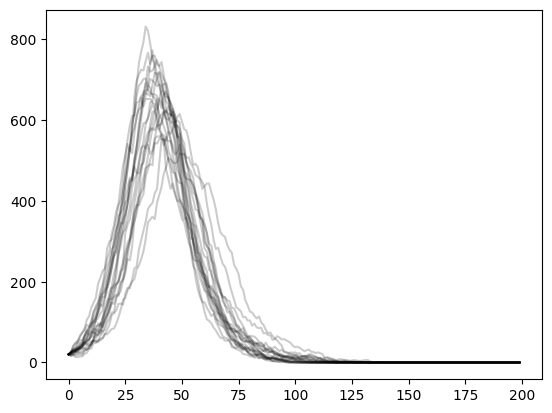

In [15]:
t_eval = np.arange(0, 200, 1)

outs = model.solve_stochastic(
    t=t_eval,
    method="fixed_tau",
    tau=0.1,
    perf=True,
    iteration=20
)

for out in outs:
    plt.plot(out.result.t, out.result.y[:, 1], color="black", alpha=0.2)
plt.show()

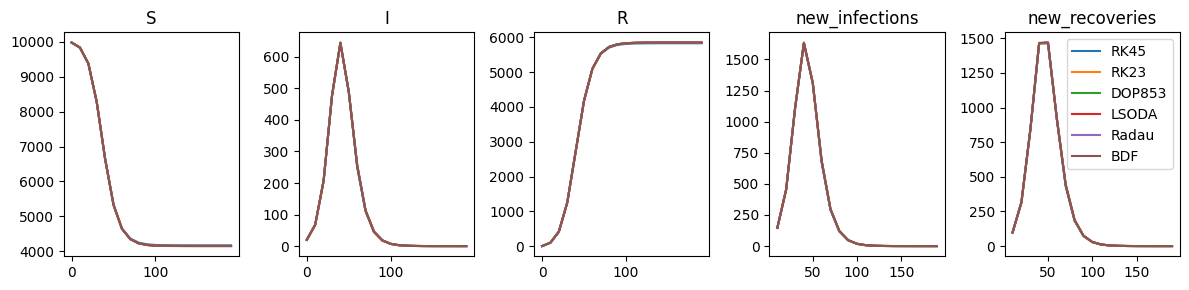

In [4]:
t_eval = np.arange(0, 200, 10)

outs = {}

methods = ['RK45', 'RK23', 'DOP853', 'LSODA', 'Radau', 'BDF']
for method in methods:
    out = model.solve_deterministic(t=t_eval, method=method)
    outs[method] = out
    
fig, ax = plt.subplots(1, n_state+n_event, figsize = (12, 3))

for i in range(n_state):
    for method in outs.keys():
        out = outs[method]
        ax[i].plot(out.result.t, out.result.y[:, i], label=method)
        ax[i].set_title(states[i])

for j in range(n_event):
    for method in outs.keys():
        out = outs[method]
        ax[i+j+1].plot(out.result.t[1:], out.result.event_counts[:, j], label=method)
        ax[i+j+1].set_title(transition_names[j])
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# All combinations of refiners and checkers

prob_refiner = {
    'refiner':'prob',
    'refiner_opts': {"max_retries":20, "acceptable_prob_misstep":0.1, "factor_min": 0.01, "factor_max": 0.4}
}
no_refiner = {
    'refiner':'none'
}

refiners = [prob_refiner, no_refiner]

checkers = [{'checker': 'forbidden_reaction'},
            {'checker': 'forbidden_state'}]

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\post_processing.py:130: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  density = np.divide(event_counts[:, i], dt, where=dt>0)


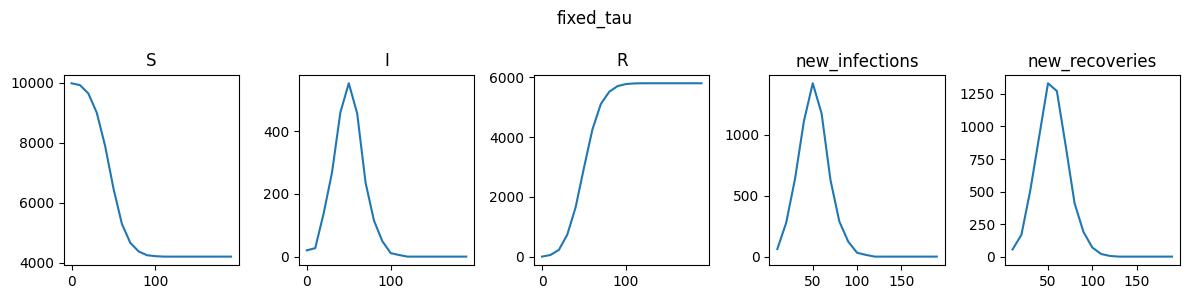

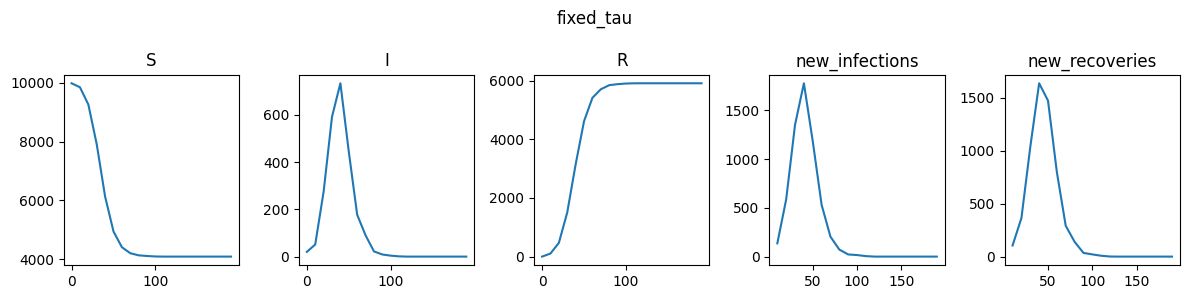

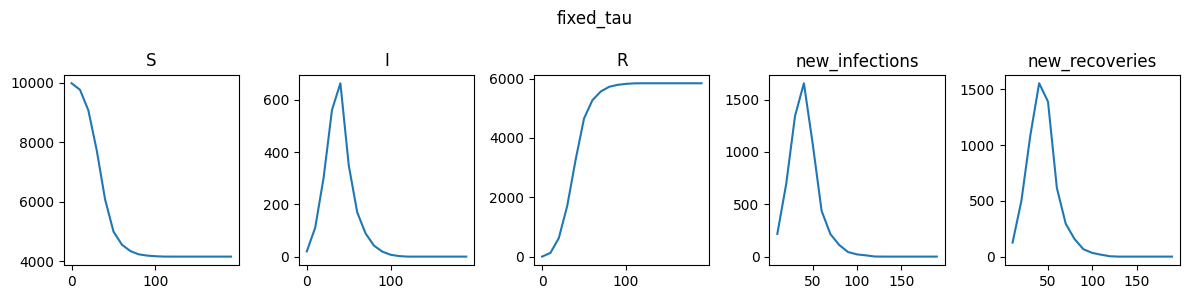

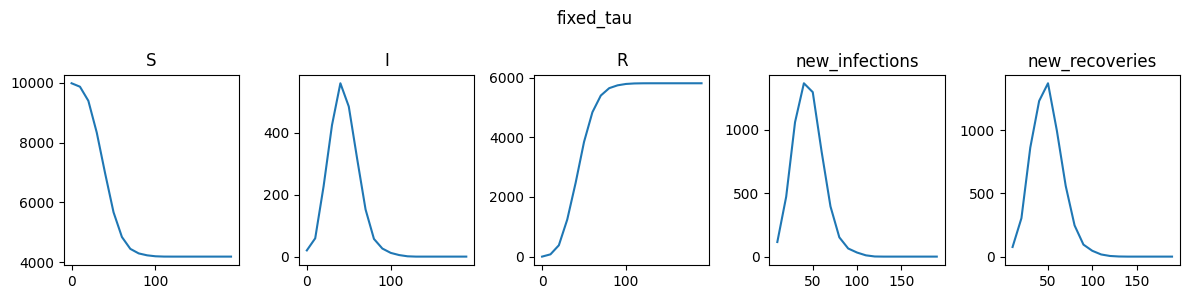

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 111.50468636502197
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


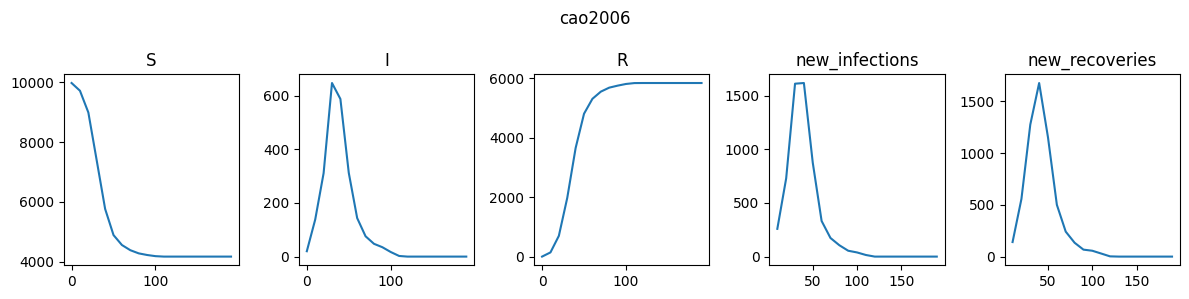

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 132.42851933596
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


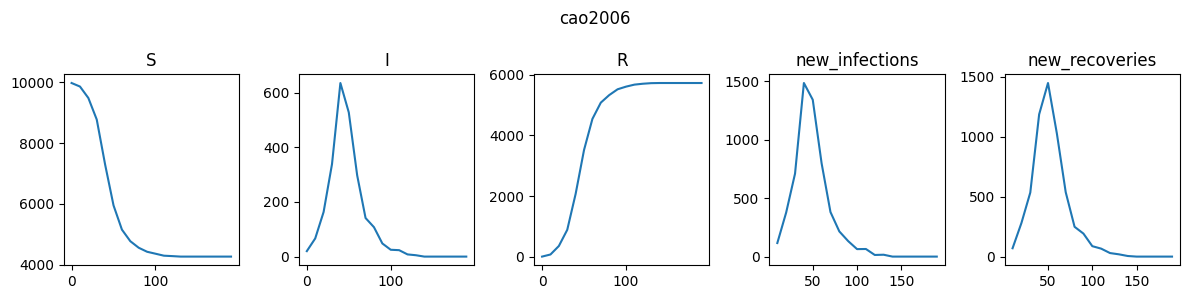

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 123.99333225609253
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


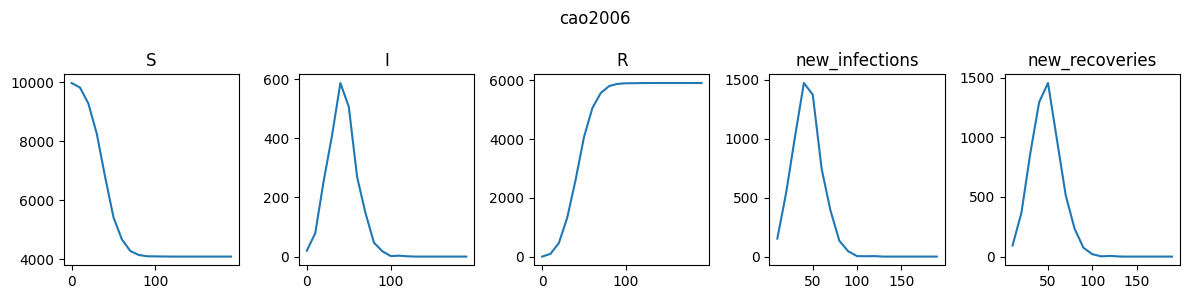

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\stochastic\core\tau\method.py:117: UserWarning: Tau selection failed: Infinite step size calculated at t = 166.19859191781515
  warnings.warn(f"Tau selection failed: Infinite step size calculated at t = {t}")


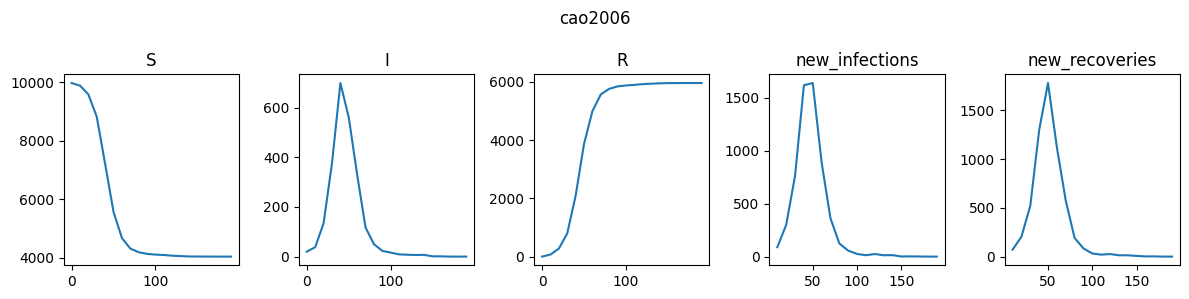

In [6]:
tau_methods = {
    'fixed_tau': {'tau': 0.1},
    'cao2006': {'epsilon': 0.03}
}

for method, option in tau_methods.items():
    for checker in checkers:
        for refiner in refiners:
            options = option | (refiner | checker)

            out = model.solve_stochastic(
                t=t_eval,
                method=method,
                perf=True,
                **options
            )

            out = out[0]

            # out = solve_stochastic(
            #     event_rates=event_rates,
            #     stoichiometry_matrix=stoichiometry_matrix,
            #     t_span=t_span,
            #     t_eval=t_eval,
            #     y0=y0,
            #     y_min=mins,
            #     y_max=maxs,
            #     method=method,
            #     perf=True,
            #     **options
            # )

            n_state = out.result.y.shape[1]

            fig, ax = plt.subplots(1, n_state+n_event, figsize = (12, 3))

            for i in range(n_state):
                ax[i].plot(out.result.t, out.result.y[:, i])
                ax[i].set_title(states[i])

            for j in range(n_event):
                ax[i+j+1].plot(out.result.t[1:], out.result.event_counts[:, j])
                ax[i+j+1].set_title(transition_names[j])
            plt.suptitle(f'{method}')
            plt.tight_layout()
            plt.show()

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\stochastic\config_api.py:73: RuntimeWarning: method='direct' does not use variables: epsilon, refiner, checker
  warnings.warn(f"method='direct' does not use variables: {', '.join(unused)}", RuntimeWarning)


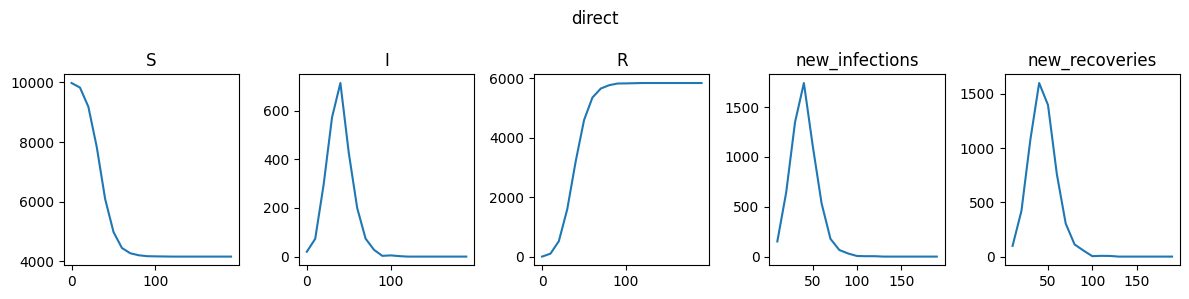

C:\Users\Joseph.Gibson\OneDrive - UK Health Security Agency\pygom\src\pygom\simulation\src\simulation\stochastic\config_api.py:79: RuntimeWarning: method='first_reaction' does not use variables: epsilon, refiner, checker
  warnings.warn(f"method='first_reaction' does not use variables: {', '.join(unused)}", RuntimeWarning)


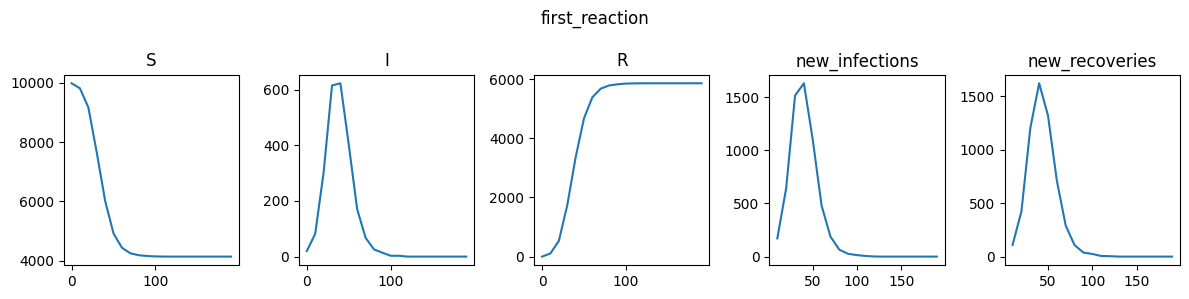

In [7]:
exact_methods = ['direct', 'first_reaction']

for method in exact_methods:
    out = model.solve_stochastic(
        t=t_eval,
        method=method,
        perf=True,
        **options)

    out = out[0]
    n_state = out.result.y.shape[1]

    fig, ax = plt.subplots(1, n_state+n_event, figsize = (12, 3))

    for i in range(n_state):
        ax[i].plot(out.result.t, out.result.y[:, i])
        ax[i].set_title(states[i])

    for j in range(n_event):
        ax[i+j+1].plot(out.result.t[1:], out.result.event_counts[:, j])
        ax[i+j+1].set_title(transition_names[j])
    plt.suptitle(f'{method}')
    plt.tight_layout()
    plt.show()